In [42]:
import matplotlib
import pickle
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sb
from scipy import stats
from scipy.stats import binom
import datetime
import statistics

from epydemix import EpiModel
from epydemix import load_predefined_model
from epydemix.visualization import plot_quantiles, plot_trajectories, plot_posterior_distribution_2d
from epydemix.population import load_epydemix_population, Population, get_available_locations
from epydemix.visualization import plot_contact_matrix, plot_population
from epydemix.utils import compute_simulation_dates
from epydemix import simulate
from epydemix.calibration import ABCSampler, rmse
import matplotlib.pyplot as plt
import pandas as pd
from epydemix.visualization import plot_posterior_distribution

from Epy_functions import stochastic_sir
from Epy_functions import stochastic_sir_noisy

In [18]:
model = stochastic_sir(0.3, 0.1, 10000, 10, 100)

In [19]:
incidence_observed = (model['incidence'])

In [20]:
incidence_df = pd.DataFrame(incidence_observed)
incidence_df = incidence_df.rename(columns={0: 'data'})
incidence_df['date'] = pd.date_range(start = '2024/01/01', periods = len(incidence_df), freq='D')
print(incidence_df)

    data       date
0      0 2024-01-01
1      3 2024-01-02
2      7 2024-01-03
3      8 2024-01-04
4      8 2024-01-05
..   ...        ...
95     3 2024-04-05
96     1 2024-04-06
97     2 2024-04-07
98     1 2024-04-08
99     0 2024-04-09

[100 rows x 2 columns]


# Full information parameter recovery

In [21]:
# Priors
priors = {"beta": stats.uniform(0, .5), 
          "gamma": stats.uniform(0.0, 0.5)}

# Simulation parameters
N = 10000
parameters = {'N': N,
              'n_i': 10,
              'timesteps': 100}

# Wrapper function
def simulate_wrapper(parameters):
    results = stochastic_sir(**parameters)
    return{'data': results['incidence']}

# Initialize the ABCSampler object
abc_sampler = ABCSampler(simulation_function=simulate_wrapper,
                         priors = priors,
                         parameters=parameters,
                         observed_data=incidence_observed)

In [22]:
results_smc = abc_sampler.calibrate(strategy='smc',
                                    num_particles=500,
                                    num_generations=10
                                    )

Starting ABC-SMC with 500 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 500/500 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 162.937396)
	Accepted 500/1435 (acceptance rate: 34.84%)
	Elapsed time: 00:00:00

Generation 3/10 (epsilon: 142.556450)
	Accepted 500/2832 (acceptance rate: 17.66%)
	Elapsed time: 00:00:00

Generation 4/10 (epsilon: 86.006037)
	Accepted 500/4609 (acceptance rate: 10.85%)
	Elapsed time: 00:00:00

Generation 5/10 (epsilon: 52.475697)
	Accepted 500/7630 (acceptance rate: 6.55%)
	Elapsed time: 00:00:01

Generation 6/10 (epsilon: 36.425128)
	Accepted 500/12598 (acceptance rate: 3.97%)
	Elapsed time: 00:00:01

Generation 7/10 (epsilon: 27.455782)
	Accepted 500/20658 (acceptance rate: 2.42%)
	Elapsed time: 00:00:01

Generation 8/10 (epsilon: 21.773931)
	Accepted 500/33114 (acceptance rate: 1.51%)
	Elapsed time: 00:00:02

Generation 9/10 (epsilon: 18.572409)
	Accepted 500/51311 (acceptance rate: 0.97%)
	Elapsed ti

<Axes: >

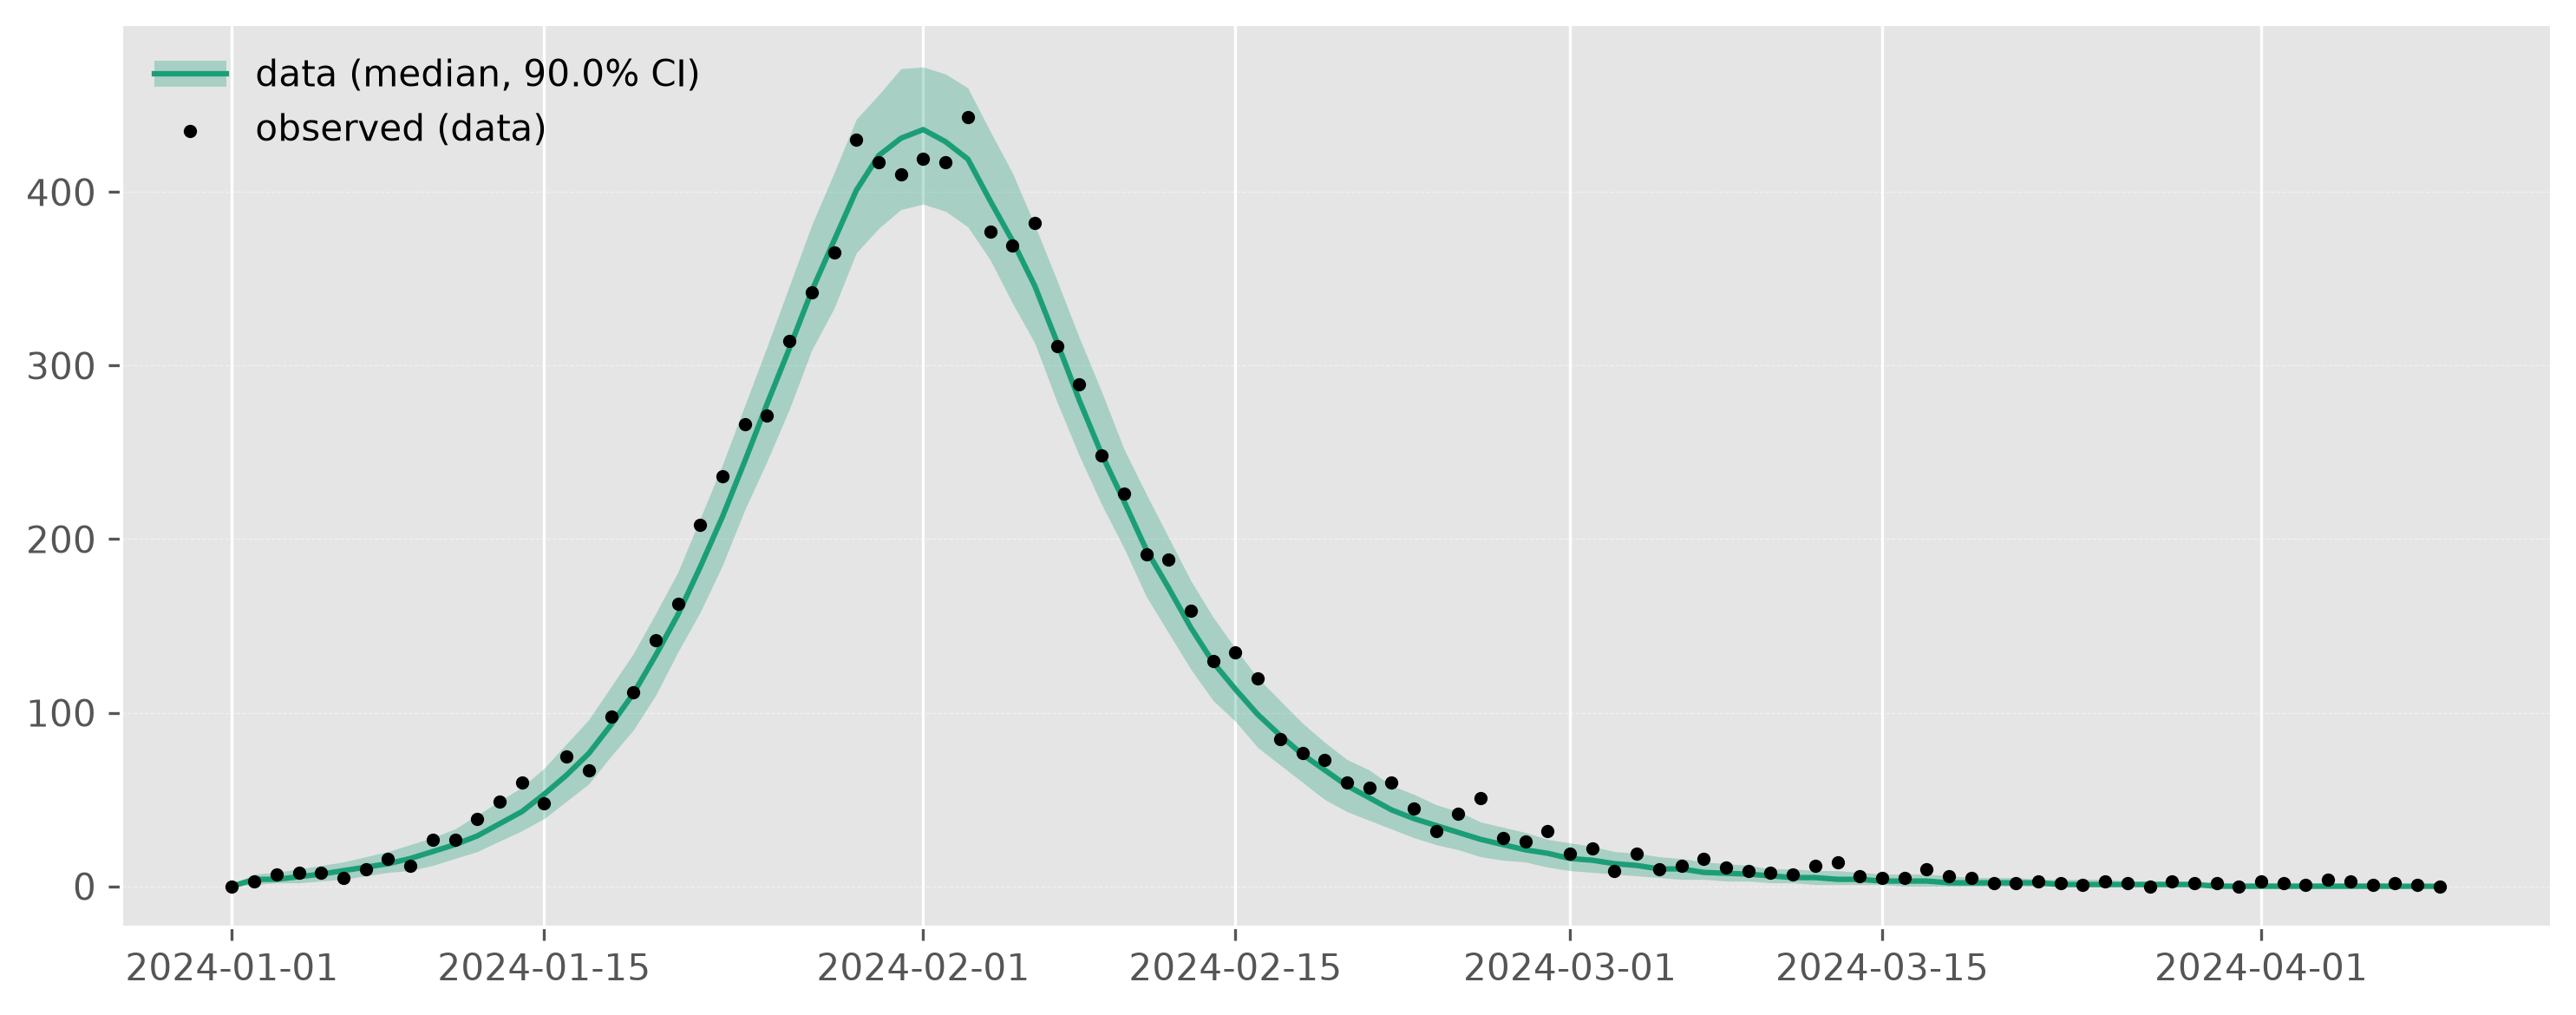

In [23]:
df_quantiles_calibration = results_smc.get_calibration_quantiles(incidence_df['date'])
plot_quantiles(df_quantiles_calibration, columns="data", data=incidence_df, show_legend=True, show_data=True)

<Axes: title={'center': 'Joint Distribution\nbeta vs gamma'}, xlabel='beta', ylabel='gamma'>

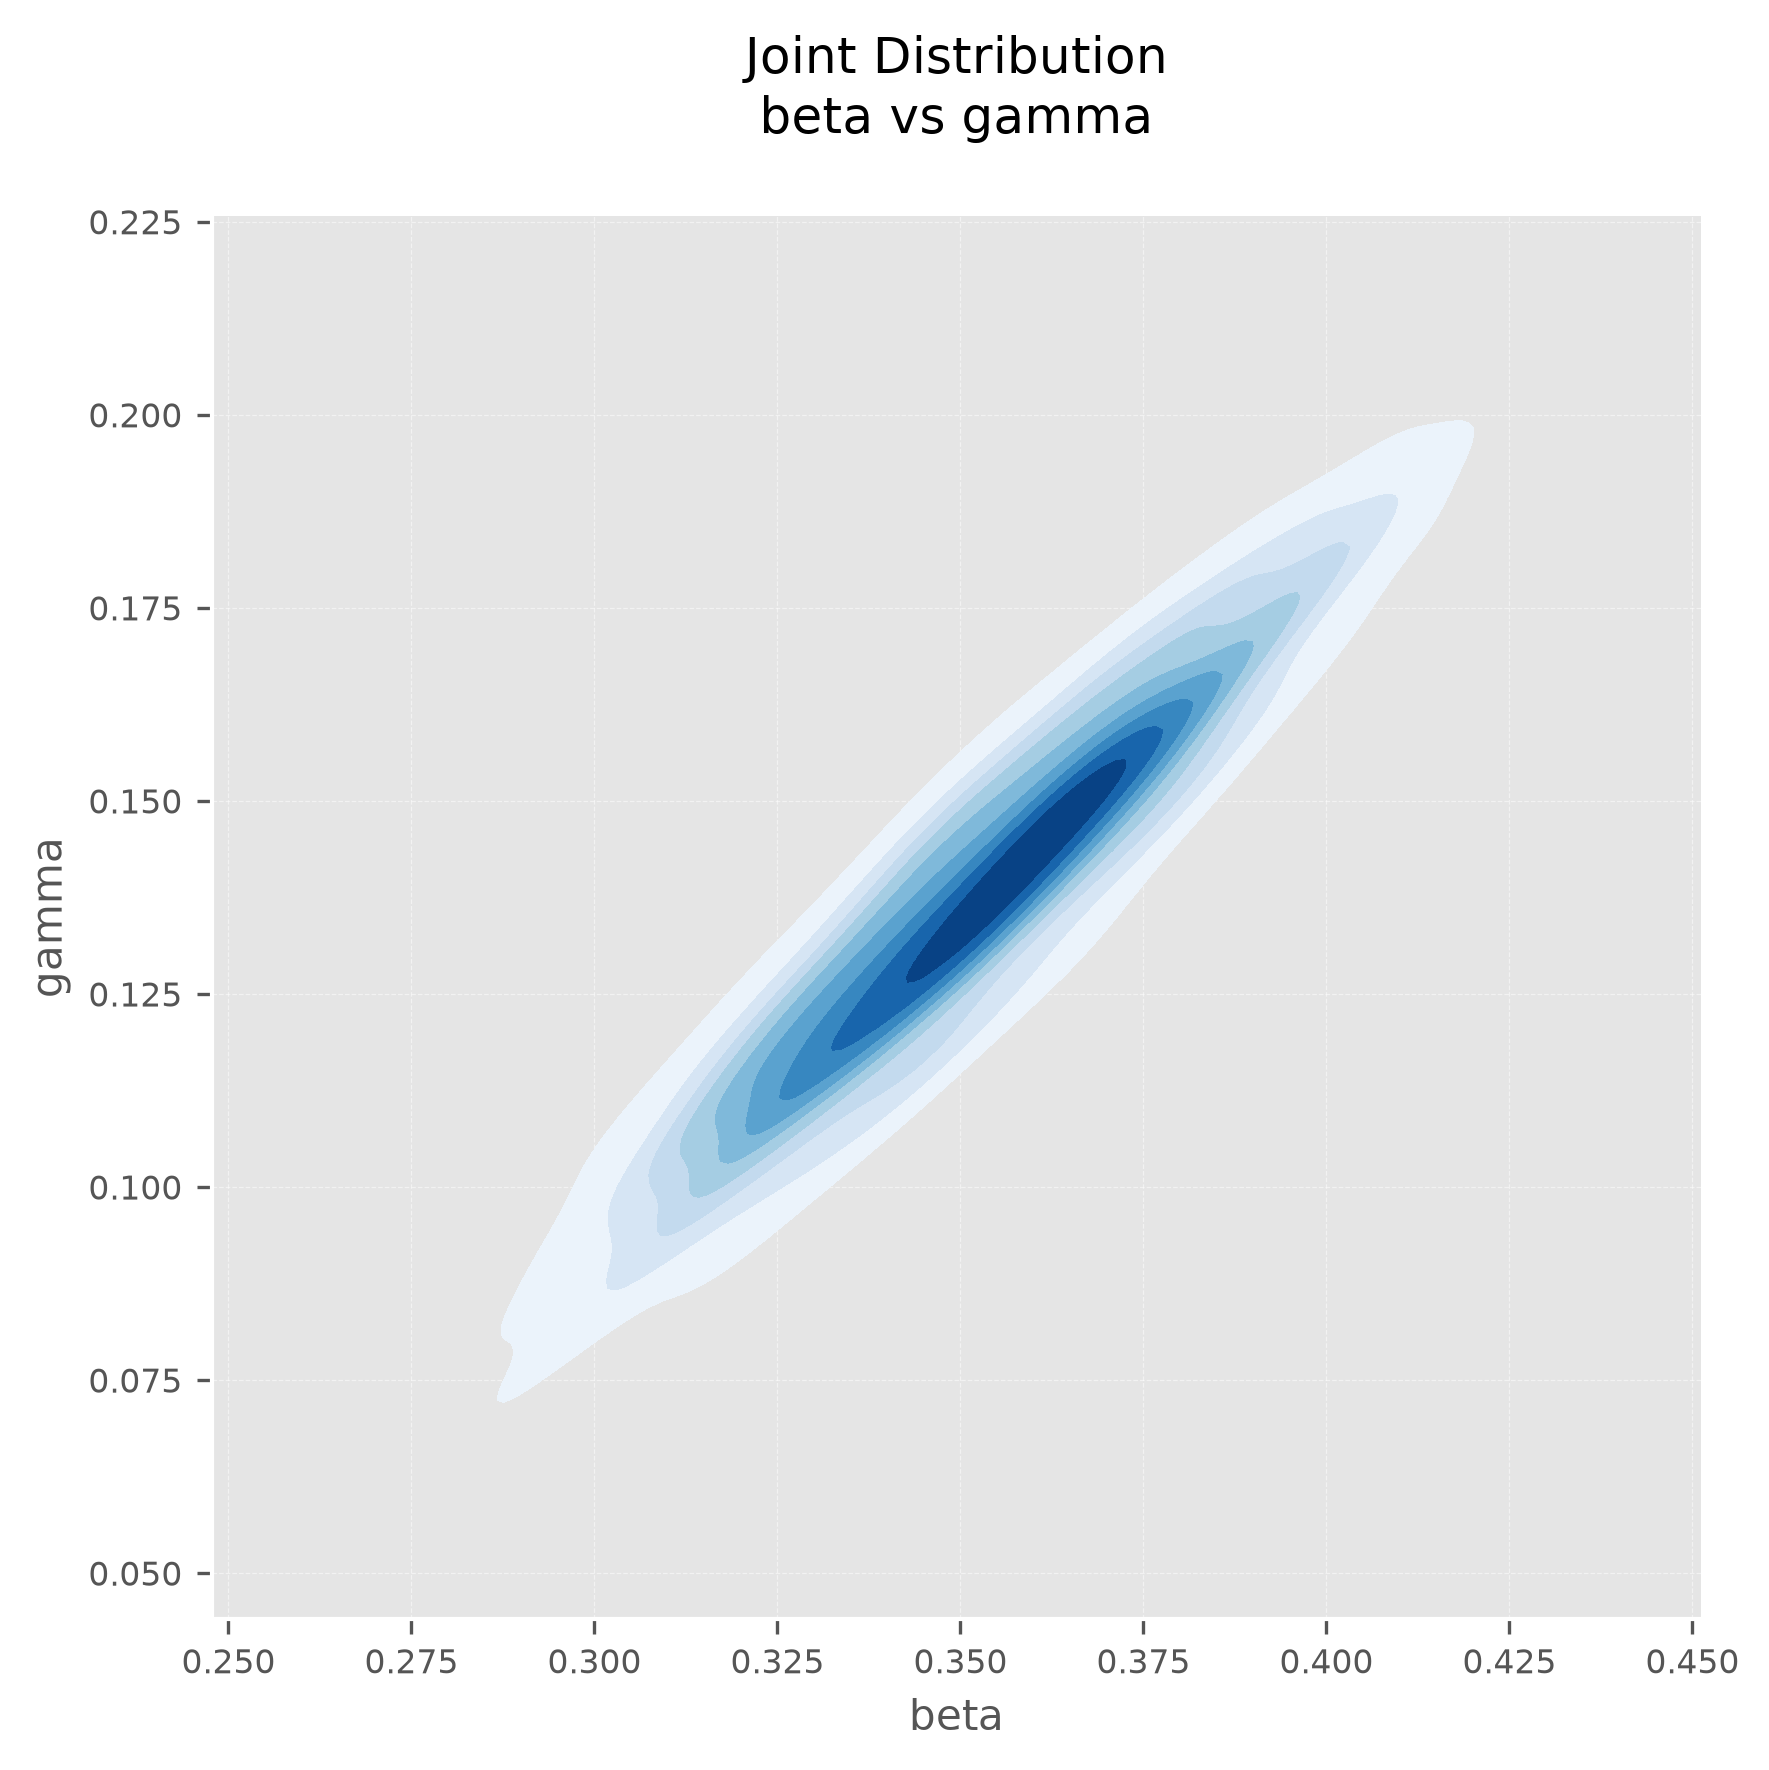

In [24]:
df_posterior = results_smc.get_posterior_distribution()
plot_posterior_distribution_2d(df_posterior, "beta", "gamma", kind="kde")

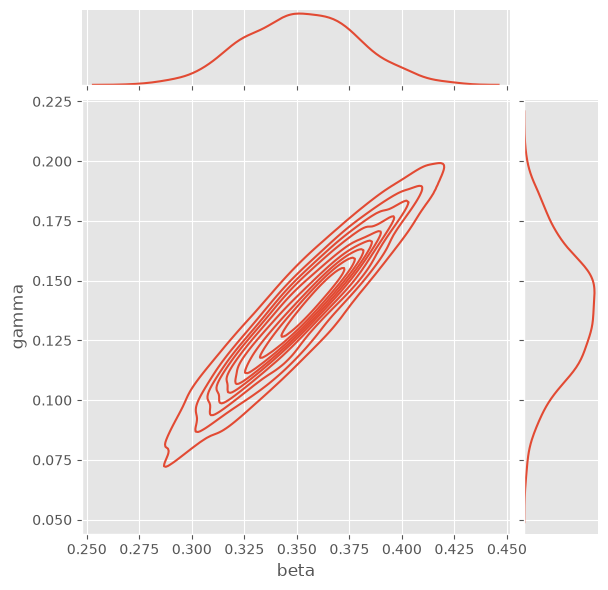

In [25]:
sb.jointplot(x = df_posterior['beta'], y = df_posterior['gamma'], kind = 'kde')
plt.xlabel('beta')
plt.ylabel('gamma')
plt.show()

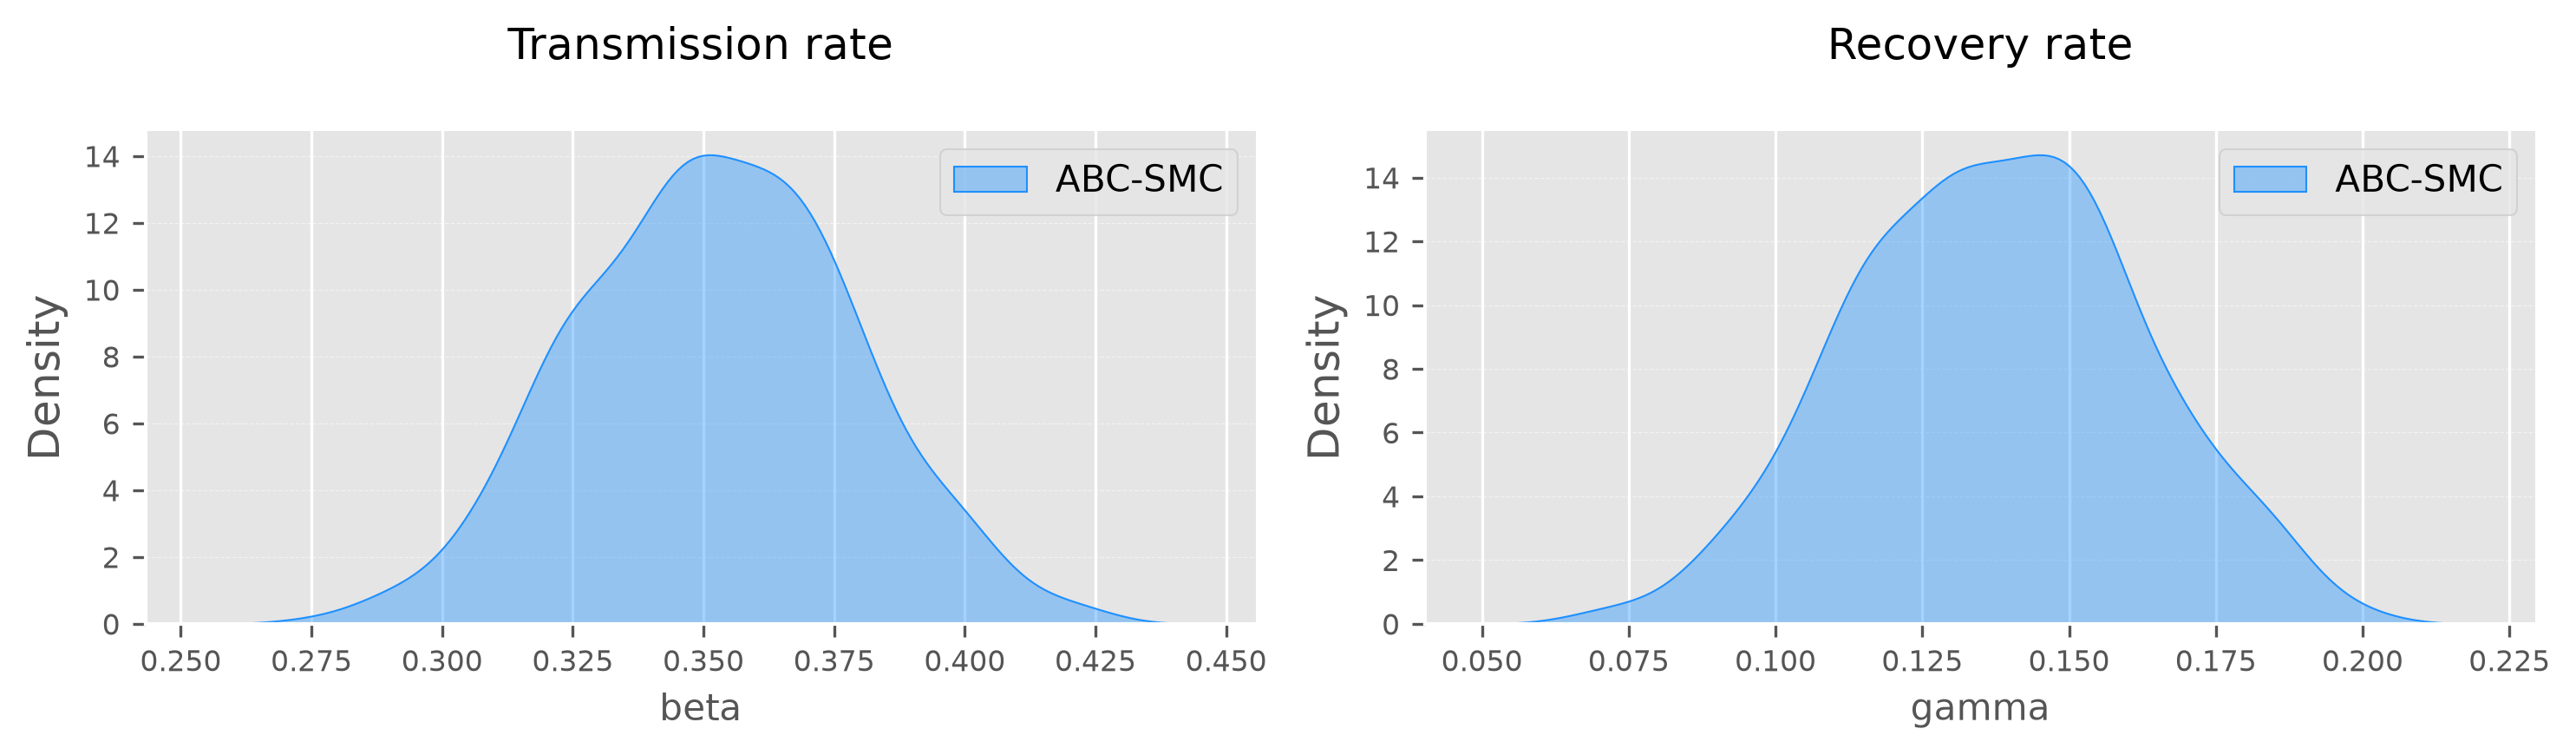

In [ ]:


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_smc.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results_smc.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

In [27]:
print(df_posterior)

         beta     gamma
0    0.349433  0.136765
1    0.342209  0.117248
2    0.360153  0.146544
3    0.408855  0.196129
4    0.353278  0.149622
..        ...       ...
495  0.373887  0.155193
496  0.352477  0.132704
497  0.362926  0.144225
498  0.349294  0.131500
499  0.336147  0.115543

[500 rows x 2 columns]


In [28]:
beta_mean = statistics.mean(df_posterior['beta'])
gamma_mean = statistics.mean(df_posterior['gamma'])

print(beta_mean)
print(gamma_mean)

0.35232116404566527
0.1375970799469978


# Overdispersed data

In [29]:
model_noisy = stochastic_sir_noisy(0.3, 0.1, 10000, 10, 100, 0.25, 2)

In [30]:
observed_noisy = model_noisy['noisy']

In [38]:
noisy_df = pd.DataFrame(observed_noisy)
noisy_df = noisy_df.rename(columns={0: 'data'})
noisy_df['date'] = pd.date_range(start = '2024/01/01', periods = len(noisy_df), freq='D')
print(noisy_df)

    data       date
0      0 2024-01-01
1      1 2024-01-02
2      0 2024-01-03
3      1 2024-01-04
4      2 2024-01-05
..   ...        ...
94     0 2024-04-04
95     0 2024-04-05
96     0 2024-04-06
97     0 2024-04-07
98     1 2024-04-08

[99 rows x 2 columns]


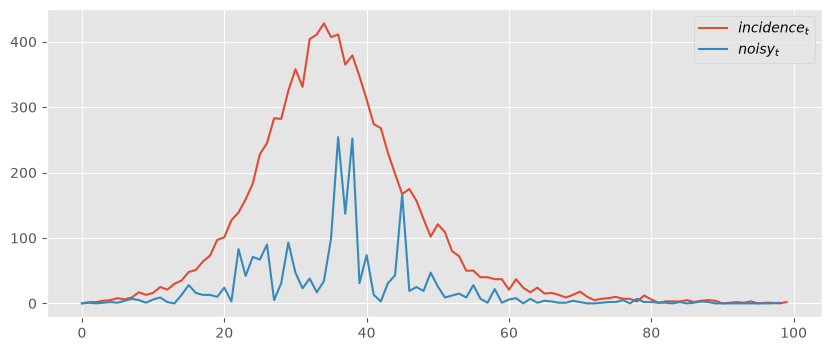

In [53]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
"""plt.plot(model_noisy['S'], label=r'$S_t$')
plt.plot(model_noisy['I'], label=r'$I_t$')
plt.plot(model_noisy['R'], label=r'$R_t$')"""
plt.plot(model_noisy['incidence'], label=r'$incidence_t$')
plt.plot(model_noisy['noisy'], label=r'$noisy_t$')
plt.legend()

In [36]:
# Simulation parameters for Noisy
parameters_noisy = {'N': N,
                    'n_i': 10,
                    'timesteps': 100,
                    'rho': 0.25,
                    'phi': 2}

# Wrapper function
def simulate_wrapper_noisy(parameters_noisy):
    results = stochastic_sir_noisy(**parameters_noisy)
    return{'data': results['noisy']}

# Initialize the ABCSampler object
abc_sampler_noisy = ABCSampler(simulation_function=simulate_wrapper_noisy,
                         priors = priors,
                         parameters=parameters_noisy,
                         observed_data=observed_noisy)

In [43]:
results_smc_noisy = abc_sampler_noisy.calibrate(strategy='smc',
                                    num_particles=1000,
                                    num_generations=10
                                    )

Starting ABC-SMC with 1000 particles and 10 generations

Generation 1/10 (epsilon: inf)
	Accepted 1000/1000 (acceptance rate: 100.00%)
	Elapsed time: 00:00:00

Generation 2/10 (epsilon: 49.673784)
	Accepted 1000/2888 (acceptance rate: 34.63%)
	Elapsed time: 00:00:02

Generation 3/10 (epsilon: 49.088459)
	Accepted 1000/5991 (acceptance rate: 16.69%)
	Elapsed time: 00:00:02

Generation 4/10 (epsilon: 44.953062)
	Accepted 1000/10361 (acceptance rate: 9.65%)
	Elapsed time: 00:00:03

Generation 5/10 (epsilon: 41.597818)
	Accepted 1000/17953 (acceptance rate: 5.57%)
	Elapsed time: 00:00:03

Generation 6/10 (epsilon: 39.175660)
	Accepted 1000/32912 (acceptance rate: 3.04%)
	Elapsed time: 00:00:05

Generation 7/10 (epsilon: 37.197195)
	Accepted 1000/61718 (acceptance rate: 1.62%)
	Elapsed time: 00:00:08

Generation 8/10 (epsilon: 35.554766)
	Accepted 1000/114638 (acceptance rate: 0.87%)
	Elapsed time: 00:00:14

Generation 9/10 (epsilon: 33.933685)
	Accepted 1000/225877 (acceptance rate: 0.44%)

<Axes: >

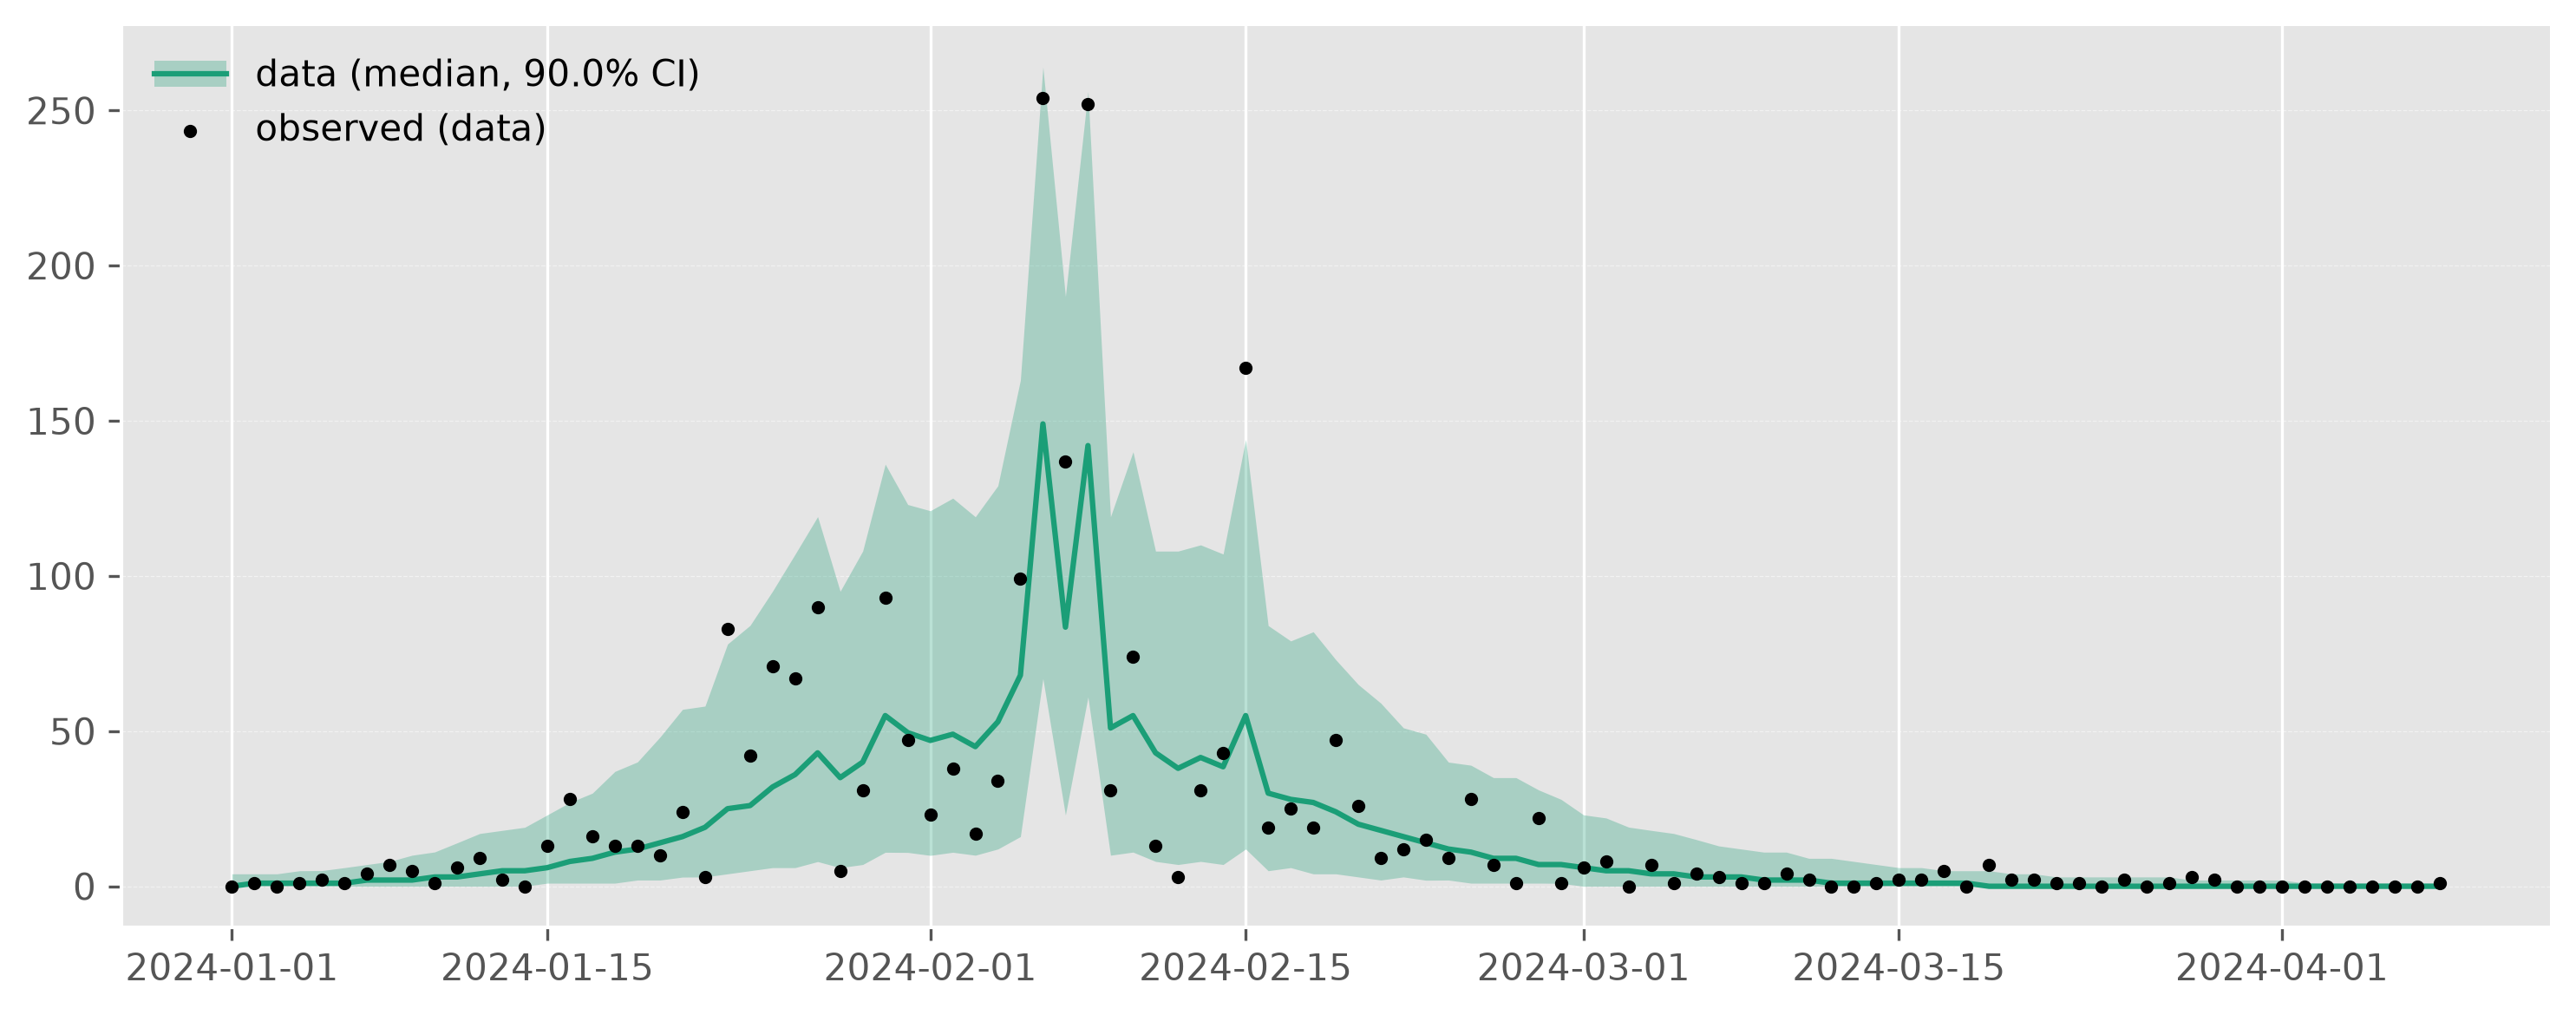

In [47]:
df_quantiles_calibration_noisy = results_smc_noisy.get_calibration_quantiles(noisy_df['date'])
plot_quantiles(df_quantiles_calibration_noisy, columns="data", data=noisy_df, show_legend=True, show_data=True)

<Axes: title={'center': 'Joint Distribution\nbeta vs gamma'}, xlabel='beta', ylabel='gamma'>

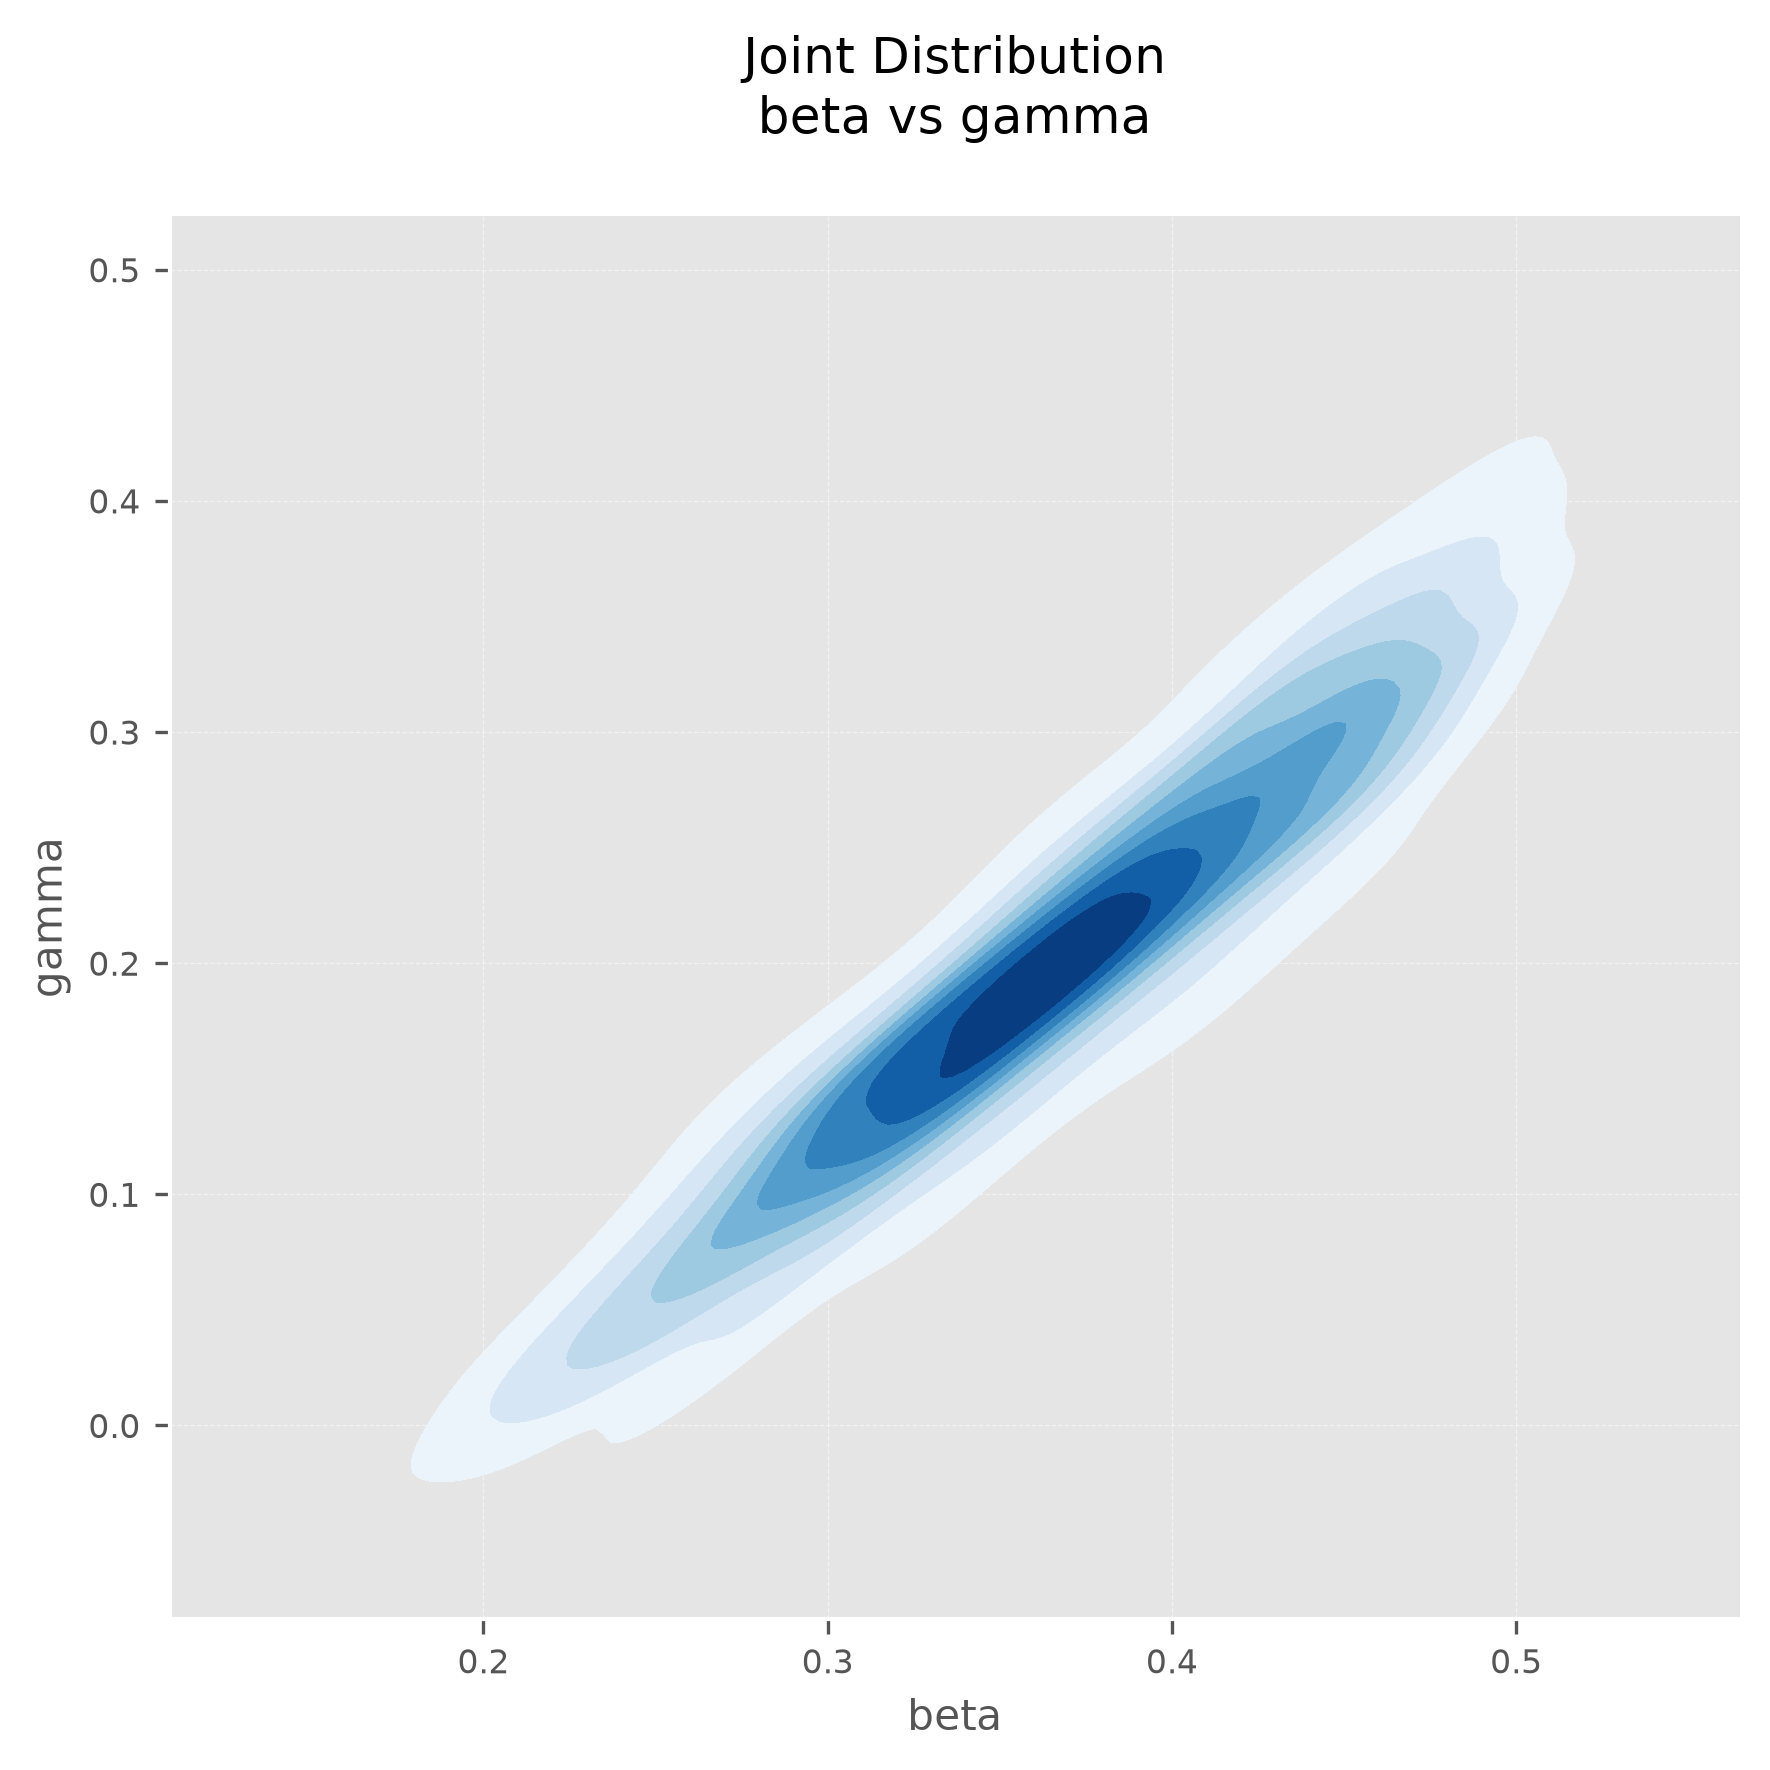

In [77]:
df_posterior_noisy = results_smc_noisy.get_posterior_distribution()
plot_posterior_distribution_2d(df_posterior_noisy, "beta", "gamma", kind="kde")

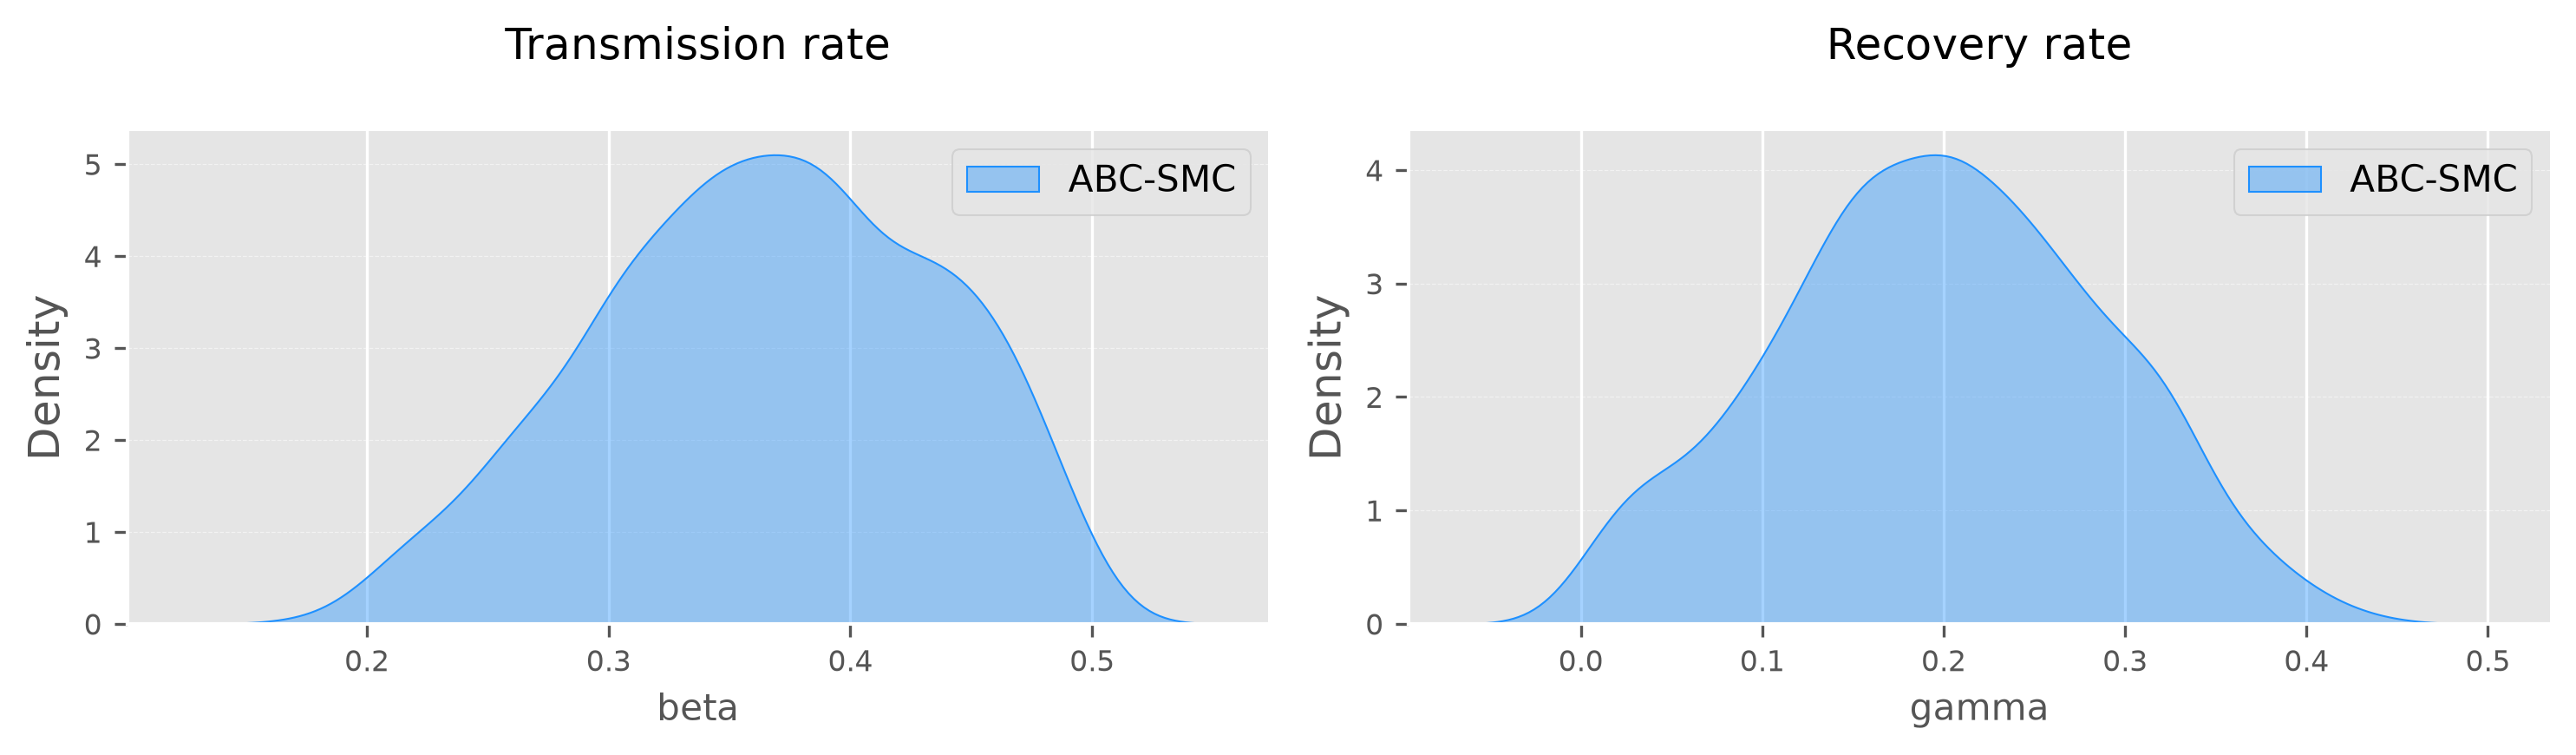

In [49]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 3), dpi=300)
plot_posterior_distribution(results_smc_noisy.get_posterior_distribution(), "beta", ax=axes[0], kind="kde", title="Transmission rate", prior_range=False, label="ABC-SMC")
axes[0].legend()    

plot_posterior_distribution(results_smc_noisy.get_posterior_distribution(), "gamma", ax=axes[1], kind="kde", title="Recovery rate", prior_range=False, label="ABC-SMC")
axes[1].legend()

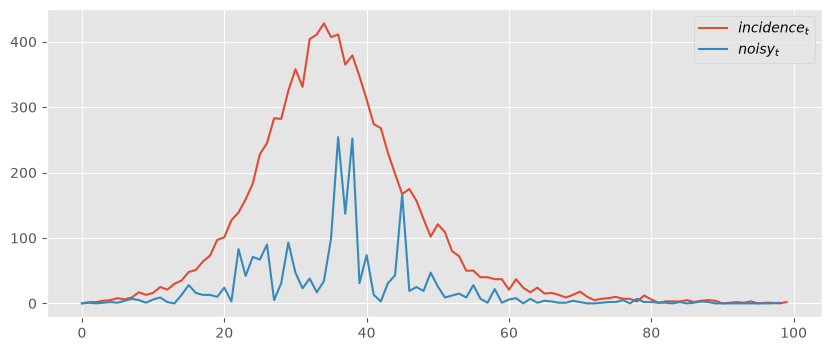

In [58]:
# Plot count of new infections, new recoveries, susceptibles, infectious, and removed
plt.style.use('ggplot')
plt.figure(figsize=(10,4))
plt.plot(model_noisy['incidence'], label=r'$incidence_t$')
plt.plot(model_noisy['noisy'], label=r'$noisy_t$')
plt.legend()

In [64]:
print(dir(results_smc_noisy))

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_compute_quantiles', '_get_generation', 'calibration_params', 'calibration_strategy', 'distances', 'get_calibration_quantiles', 'get_calibration_trajectories', 'get_distances', 'get_posterior_distribution', 'get_projection_quantiles', 'get_projection_trajectories', 'get_selected_trajectories', 'get_weights', 'observed_data', 'posterior_distributions', 'priors', 'projection_parameters', 'projections', 'selected_trajectories', 'weights']


In [88]:
print(results_smc_noisy.posterior_distributions)

{0:          beta     gamma
0    0.425571  0.330097
1    0.044716  0.001269
2    0.320282  0.489406
3    0.023402  0.470178
4    0.023141  0.391279
..        ...       ...
995  0.256477  0.208760
996  0.268336  0.359911
997  0.350854  0.378651
998  0.097670  0.054738
999  0.203999  0.193480

[1000 rows x 2 columns], 1:          beta     gamma
0    0.331105  0.457370
1    0.262925  0.280206
2    0.388577  0.260397
3    0.374086  0.380703
4    0.422390  0.177767
..        ...       ...
995  0.065487  0.031301
996  0.049317  0.053257
997  0.274584  0.407101
998  0.407463  0.266693
999  0.402297  0.235710

[1000 rows x 2 columns], 2:          beta     gamma
0    0.474397  0.251084
1    0.391535  0.316904
2    0.372792  0.209098
3    0.274808  0.234903
4    0.491169  0.366549
..        ...       ...
995  0.365910  0.219912
996  0.361060  0.378478
997  0.331521  0.182278
998  0.337204  0.167618
999  0.471408  0.392552

[1000 rows x 2 columns], 3:          beta     gamma
0    0.444453  0.2960

In [83]:
print(results_smc_noisy.weights)

{0: array([0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001, 0.001,
       0.001, 0.

In [96]:
beta_noisy_mean = statistics.mean(df_posterior_noisy['beta'])
gamma_noisy_mean = statistics.mean(df_posterior_noisy['gamma'])

print(beta_noisy_mean)
print(gamma_noisy_mean)

0.36536448816412853
0.19811430148079812
